#Introduction

In this project, I examine how economic development relates to improvements in access to electricity. I use two datasets from the World Bank: GDP per capita and Access to Electricity. Since the assignment asks for two datasets to be combined into a single visualization, I focus on countries where both indicators show meaningful changes over time. I select India, Bangladesh, Kenya, Vietnam, and Indonesia because they experienced large increases in electrification during the past two decades, together with steady growth in income levels.

After cleaning and merging the datasets using Python and pandas, I create visualizations that track each country’s progress over time and compare their positions in terms of GDP and electricity access. The goal is not to prove a causal relationship, but to observe general patterns and understand how economic development and infrastructure expansion evolve together in different national contexts.

In [ ]:
#cleaning the dataset of gdp first

import pandas as pd

gdp = pd.read_csv("gdp_original.csv", skiprows=4)
gdp.head()

year_cols = [c for c in gdp.columns if c.isdigit()]
keep_cols = ["Country Name"] + year_cols

gdp_clean = gdp[keep_cols].rename(columns={"Country Name": "Country"})

gdp_long = gdp_clean.melt(id_vars="Country",
                          var_name="Year",
                          value_name="GDP")

gdp_long["Year"] = pd.to_numeric(gdp_long["Year"], errors="coerce")
gdp_long = gdp_long.dropna(subset=["Year"])
gdp_long["Year"] = gdp_long["Year"].astype(int)

gdp_long.to_csv("gdp.csv", index=False)



In [ ]:
import pandas as pd

access = pd.read_csv("access.csv")

year_cols = [col for col in access.columns if "[YR" in col]

keep_cols = ["Country Name"] + year_cols
access_clean = access[keep_cols].rename(columns={"Country Name": "Country"})

access_clean.columns = [
    col.split(" ")[0] if "[YR" in col else col
    for col in access_clean.columns
]

access_long = access_clean.melt(
    id_vars="Country",
    var_name="Year",
    value_name="Access"
)

access_long["Year"] = access_long["Year"].astype(int)

access_long["Access"] = pd.to_numeric(access_long["Access"], errors="coerce")

access_long.to_csv("access_cleaned.csv", index=False)

access_long.head()


,Country,Year,Access
0,Afghanistan,1990,NaN
1,Albania,1990,100.0
2,Algeria,1990,NaN
3,American Samoa,1990,NaN
4,Andorra,1990,100.0


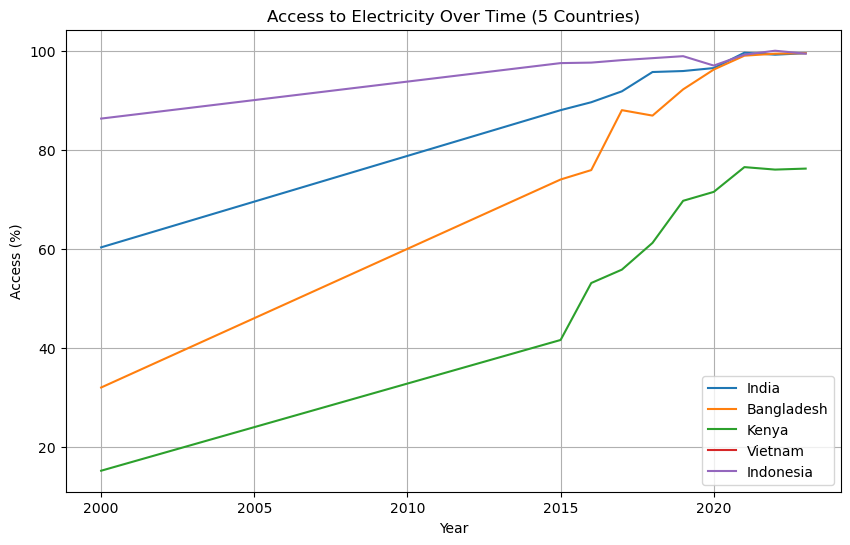

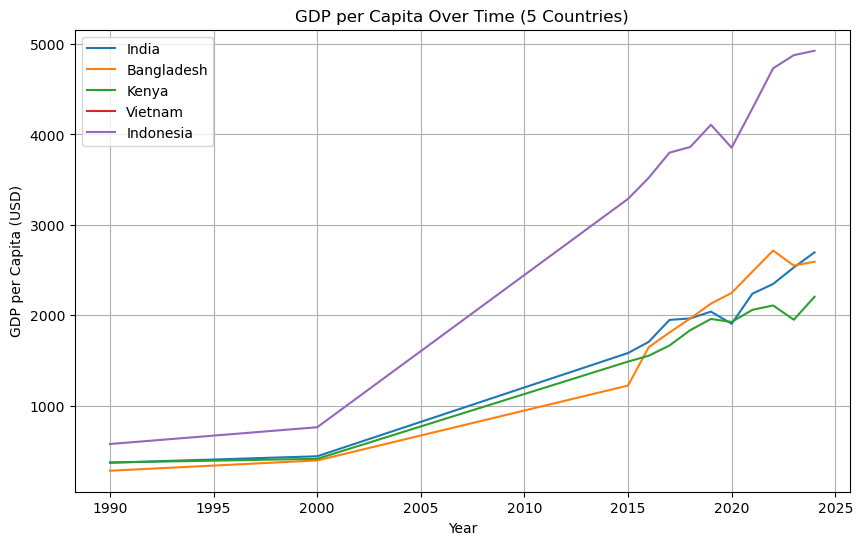

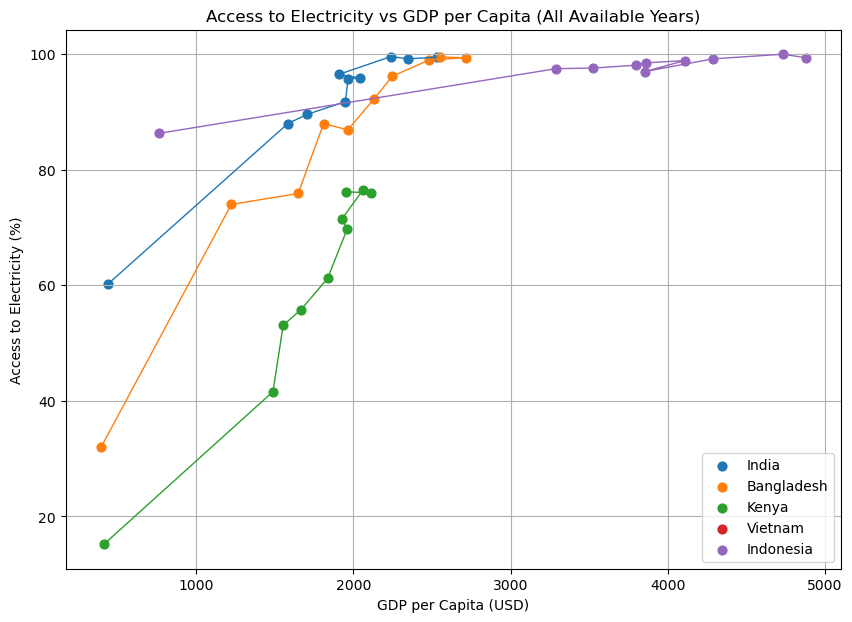

In [21]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

access = pd.read_csv("access_cleaned.csv")
gdp = pd.read_csv("gdp.csv")

access.head(), gdp.head()

merged = pd.merge(access, gdp, on=["Country", "Year"], how="inner")
merged.head()

countries = ["India", "Bangladesh", "Kenya", "Vietnam", "Indonesia"]
subset = merged[merged["Country"].isin(countries)]

plt.figure(figsize=(10,6))

for c in countries:
    df = subset[subset["Country"] == c]
    plt.plot(df["Year"], df["Access"], label=c)

plt.title("Access to Electricity Over Time (5 Countries)")
plt.xlabel("Year")
plt.ylabel("Access (%)")
plt.legend()
plt.grid(True)
plt.show()



plt.figure(figsize=(10,6))

for c in countries:
    df = subset[subset["Country"] == c]
    plt.plot(df["Year"], df["GDP"], label=c)

plt.title("GDP per Capita Over Time (5 Countries)")
plt.xlabel("Year")
plt.ylabel("GDP per Capita (USD)")
plt.legend()
plt.grid(True)
plt.show()

latest_year = subset["Year"].max()
plot_df = subset[subset["Year"] == latest_year].dropna(subset=["GDP","Access"])


plt.figure(figsize=(10,7))

for country in countries:
    df = subset[subset["Country"] == country]
    plt.scatter(df["GDP"], df["Access"], label=country, s=40)
    plt.plot(df["GDP"], df["Access"], linewidth=1)   # trajectory

plt.title("Access to Electricity vs GDP per Capita (All Available Years)")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Access to Electricity (%)")
plt.legend()
plt.grid(True)
plt.show()


#Takeaways

1. All five countries show a clear positive relationship between GDP per capita and electricity access. As income rises, the share of the population with access also increases, although the pace differs across countries.

2. Bangladesh and Kenya exhibit the sharpest improvements. Both started with very low access levels around 2000, but made rapid progress as their economies expanded. Their trajectories show how electrification efforts accelerate once basic economic conditions improve.

3. India shows steady and gradual progress, with both GDP per capita and access increasing in parallel. The pattern is smoother and less volatile than in Kenya or Bangladesh, reflecting its larger and more diversified economy.

4. Indonesia achieved high access earlier than the others. Their data suggest that strong policy commitment and infrastructure planning can push electrification ahead of income growth, especially in middle-income countries.

5. When all available years are plotted in a single scatter chart, the combined pattern forms an upward-sloping cloud. This shows that, despite differences between countries, economic growth and electrification tend to move together over time.